<a href="https://colab.research.google.com/github/vijaybsbs/yulu_business_case/blob/main/Yulu_Busines_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
                <font color="#0F95E9" size="6">
                    <b>Yulu Business Case Study - Hypothesis Testing </b>



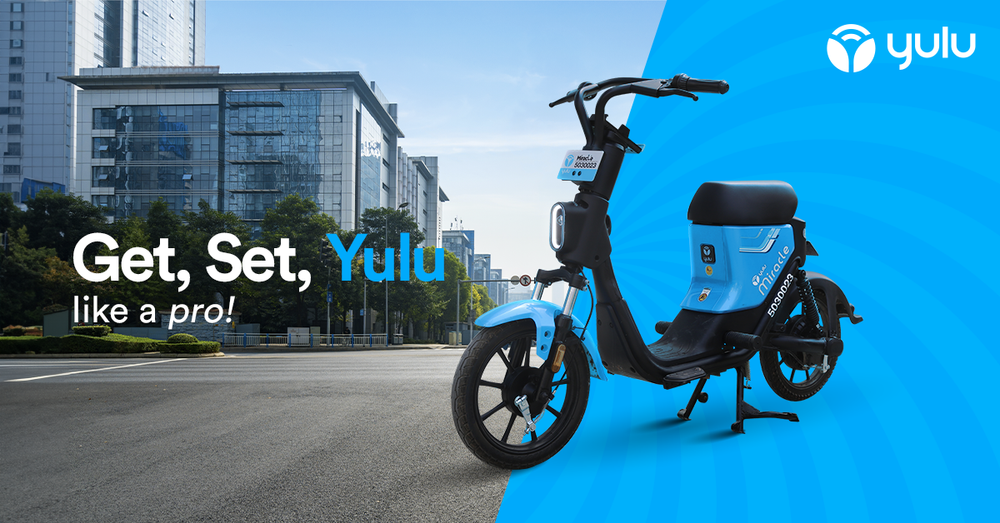

# **About Yulu**

Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

# **The company wants to know:**

* Which variables are significant in predicting the demand for shared electric cycles in the Indian market?

* How well those variables describe the electric cycle demands

# **1. Importing Libraries & Data**

In [284]:
# impoting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import (
    ttest_ind,
    levene,
    f_oneway,
    chi2_contingency,
    shapiro
)
import random

import warnings
warnings.filterwarnings('ignore')

In [285]:
from google.colab import files

uploaded = files.upload()

Saving yulu.csv to yulu (3).csv


In [286]:
df = pd.read_csv('yulu.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


# **2. Exploratory Data Analysis**

In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [288]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [289]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [290]:
df.duplicated().value_counts()

,count
False,10886


# **Insight**

- The dataset contains **10,886 rows and 12 columns**, representing 10,886 hourly observations across **4 seasons and 4 weather conditions.**

- There are `no duplicate records and no missing (null) values`, indicating good data quality.

- The `datetime` column is currently stored as an object data type and should be converted to `datetime64` to enable efficient date and time manipulation.

- The columns `season`, `holiday`, `workingday`, and `weather` should be converted to the category data type to improve memory efficiency and facilitate categorical analysis.

# **2.1 Category Conversion**

In [291]:
df['datetime'] = pd.to_datetime(df['datetime'])

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.day_name()
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour

df['season'] = df['season'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['workingday'] = df['workingday'].astype('category')
df['weather'] = df['weather'].astype('category')

In [292]:
def season_category(season):
    if season == 1:
        return 'spring'
    elif season == 2:
        return 'summer'
    elif season == 3:
        return 'fall'
    else:
        return 'winter'
df['season'] = df['season'].apply(season_category)

In [293]:
def weather_category(weather):
    if weather == 1:
        return 'clear'
    elif weather == 2:
        return 'mist'
    elif weather == 3:
        return 'light_snow'
    else:
        return 'heavy_rain'
df['weather'] = df['weather'].apply(weather_category)

In [294]:
def holiday_category(holiday):
    if holiday == 0:
        return 'no_holiday'
    else:
        return 'holiday'
df['holiday'] = df['holiday'].apply(holiday_category)

In [295]:
def  workingday_category(workingday):
    if workingday == 0:
        return 'no_working_day'
    else:
        return 'working_day'
df['workingday'] = df['workingday'].apply(workingday_category)

In [296]:
display(df.describe(include='category'))
display(df['season'].value_counts())

,season,holiday,workingday,weather
count,10886,10886,10886,10886
unique,4,2,2,4
top,winter,no_holiday,working_day,clear
freq,2734,10575,7412,7192


,count
season,
winter,2734
summer,2733
fall,2733
spring,2686


In [297]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  weekday     10886 non-null  object        
 15  day         10886 non-null  int32         
 16  hour        10886 non-

In [298]:
df.tail(20)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,weekday,day,hour
10866,2012-12-19 04:00:00,winter,no_holiday,working_day,clear,9.84,12.120,75,8.9981,1,6,7,2012,12,Wednesday,19,4
10867,2012-12-19 05:00:00,winter,no_holiday,working_day,clear,10.66,14.395,75,6.0032,2,29,31,2012,12,Wednesday,19,5
10868,2012-12-19 06:00:00,winter,no_holiday,working_day,clear,9.84,12.880,75,6.0032,3,109,112,2012,12,Wednesday,19,6
10869,2012-12-19 07:00:00,winter,no_holiday,working_day,clear,10.66,13.635,75,8.9981,3,360,363,2012,12,Wednesday,19,7
10870,2012-12-19 08:00:00,winter,no_holiday,working_day,clear,9.84,12.880,87,7.0015,13,665,678,2012,12,Wednesday,19,8
10871,2012-12-19 09:00:00,winter,no_holiday,working_day,clear,11.48,14.395,75,7.0015,8,309,317,2012,12,Wednesday,19,9
10872,2012-12-19 10:00:00,winter,no_holiday,working_day,clear,13.12,16.665,70,7.0015,17,147,164,2012,12,Wednesday,19,10
10873,2012-12-19 11:00:00,winter,no_holiday,working_day,clear,16.40,20.455,54,15.0013,31,169,200,2012,12,Wednesday,19,11
10874,2012-12-19 12:00:00,winter,no_holiday,working_day,clear,16.40,20.455,54,19.0012,33,203,236,2012,12,Wednesday,19,12
10875,2012-12-19 13:00:00,winter,no_holiday,working_day,clear,17.22,21.210,50,12.9980,30,183,213,2012,12,Wednesday,19,13


In [299]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,2011.501929,6.521495,9.992559,11.541613
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000,1.000000,1.000000,0.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,2011.000000,4.000000,5.000000,6.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,2012.000000,7.000000,10.000000,12.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,2012.000000,10.000000,15.000000,18.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,2012.000000,12.000000,19.000000,23.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,0.500019,3.444373,5.476608,6.915838


In [300]:
df.describe(include='category')

,season,holiday,workingday,weather
count,10886,10886,10886,10886
unique,4,2,2,4
top,winter,no_holiday,working_day,clear
freq,2734,10575,7412,7192


# **Insight**

- The dataset looks like **hourly bike demand** with `moderate-to-high variability.` Average ridership is about **192 rides**, but the spread is wide, so demand changes a lot over time.

- **Weather seems important**. Temperature is fairly mild on average at about 20.2°C, while humidity is somewhat high at 61.9%. Wind speed is usually low, which suggests extreme wind conditions are rare.

- A big pattern is that **registered users drive most of the demand**. On average, `registered rides are about 156`, versus only `36 casual rides`, so repeat users make up the majority of traffic.

- The count ranges from `1 to 977`, which shows there are some **very low-demand periods and some strong peak periods.**

# **2.2 Detailed Analysis**

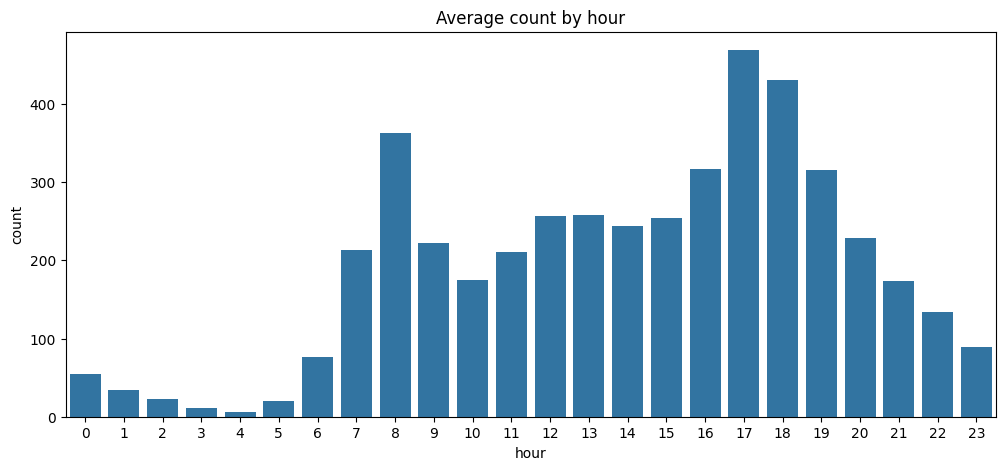

In [301]:
#Time based analysis
plt.figure(figsize=(12, 5))
sns.barplot(x="hour", y="count", data=df, errorbar=None)
plt.title("Average count by hour")
plt.show()

# **Insight**

- The average bike rental count is `lowest during late night and early morning hours` (12 AM – 5 AM).

- Rentals start `increasing from 6 AM, with a morning peak at 8 AM`, likely due to commuters `traveling to work or school`.

- The demand remains moderate and stable from 9 AM to 4 PM.

- The highest rental count occurs at `5 PM (17:00), followed by 6 PM (18:00), indicating strong evening commute demand`.

- After 7 PM, the rental count gradually decreases and continues to decline through the night.

- Overall, the chart shows two clear demand peaks: one in the morning (8 AM) and another, larger peak in the evening (5–6 PM), reflecting typical daily commuting patterns.

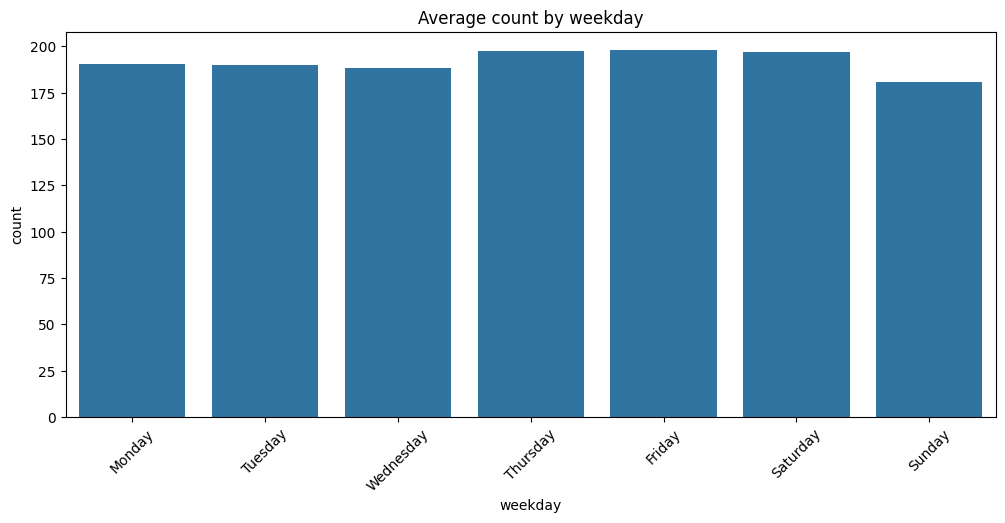

In [302]:
plt.figure(figsize=(12, 5))
sns.barplot(
    x="weekday",
    y="count",
    data=df,
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    errorbar=None
)
plt.xticks(rotation=45)
plt.title("Average count by weekday")
plt.show()

# **Insights**

- The average bike rental count is **fairly consistent across all weekdays**, indicating stable demand throughout the week.

- `Sunday records the lowest average rental count`, suggesting lower bike usage on weekends.

- Monday to Wednesday show similar average rental counts with only minor variations.

- Overall, `weekday has a limited impact on bike rentals`, as the average counts remain relatively uniform across the week.

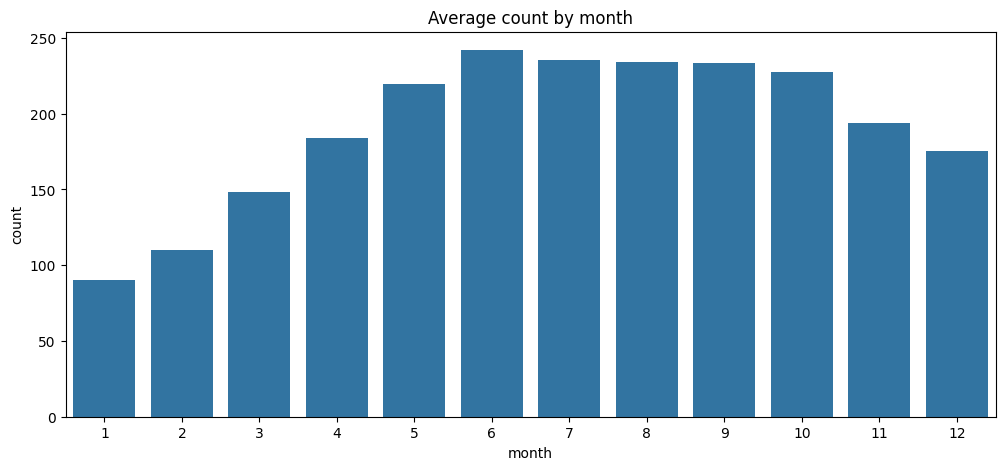

In [303]:
plt.figure(figsize=(12, 5))
sns.barplot(x="month", y="count", data=df, errorbar=None)
plt.title("Average count by month")
plt.show()

# **Insight**

- The average bike rental count **increases steadily from January to June**, indicating growing demand during the first half of the year.

- `June records the highest average rental count`, making it the peak month for bike rentals.

- `Rental demand remains consistently high from July to October`, with only slight variations.

- After October, `the average rental count declines in November and December`.

- `January has the lowest average rental count`, suggesting reduced bike usage during the winter season.

- Overall, bike rentals are `highest during the summer and early autumn` months and lowest during winter.

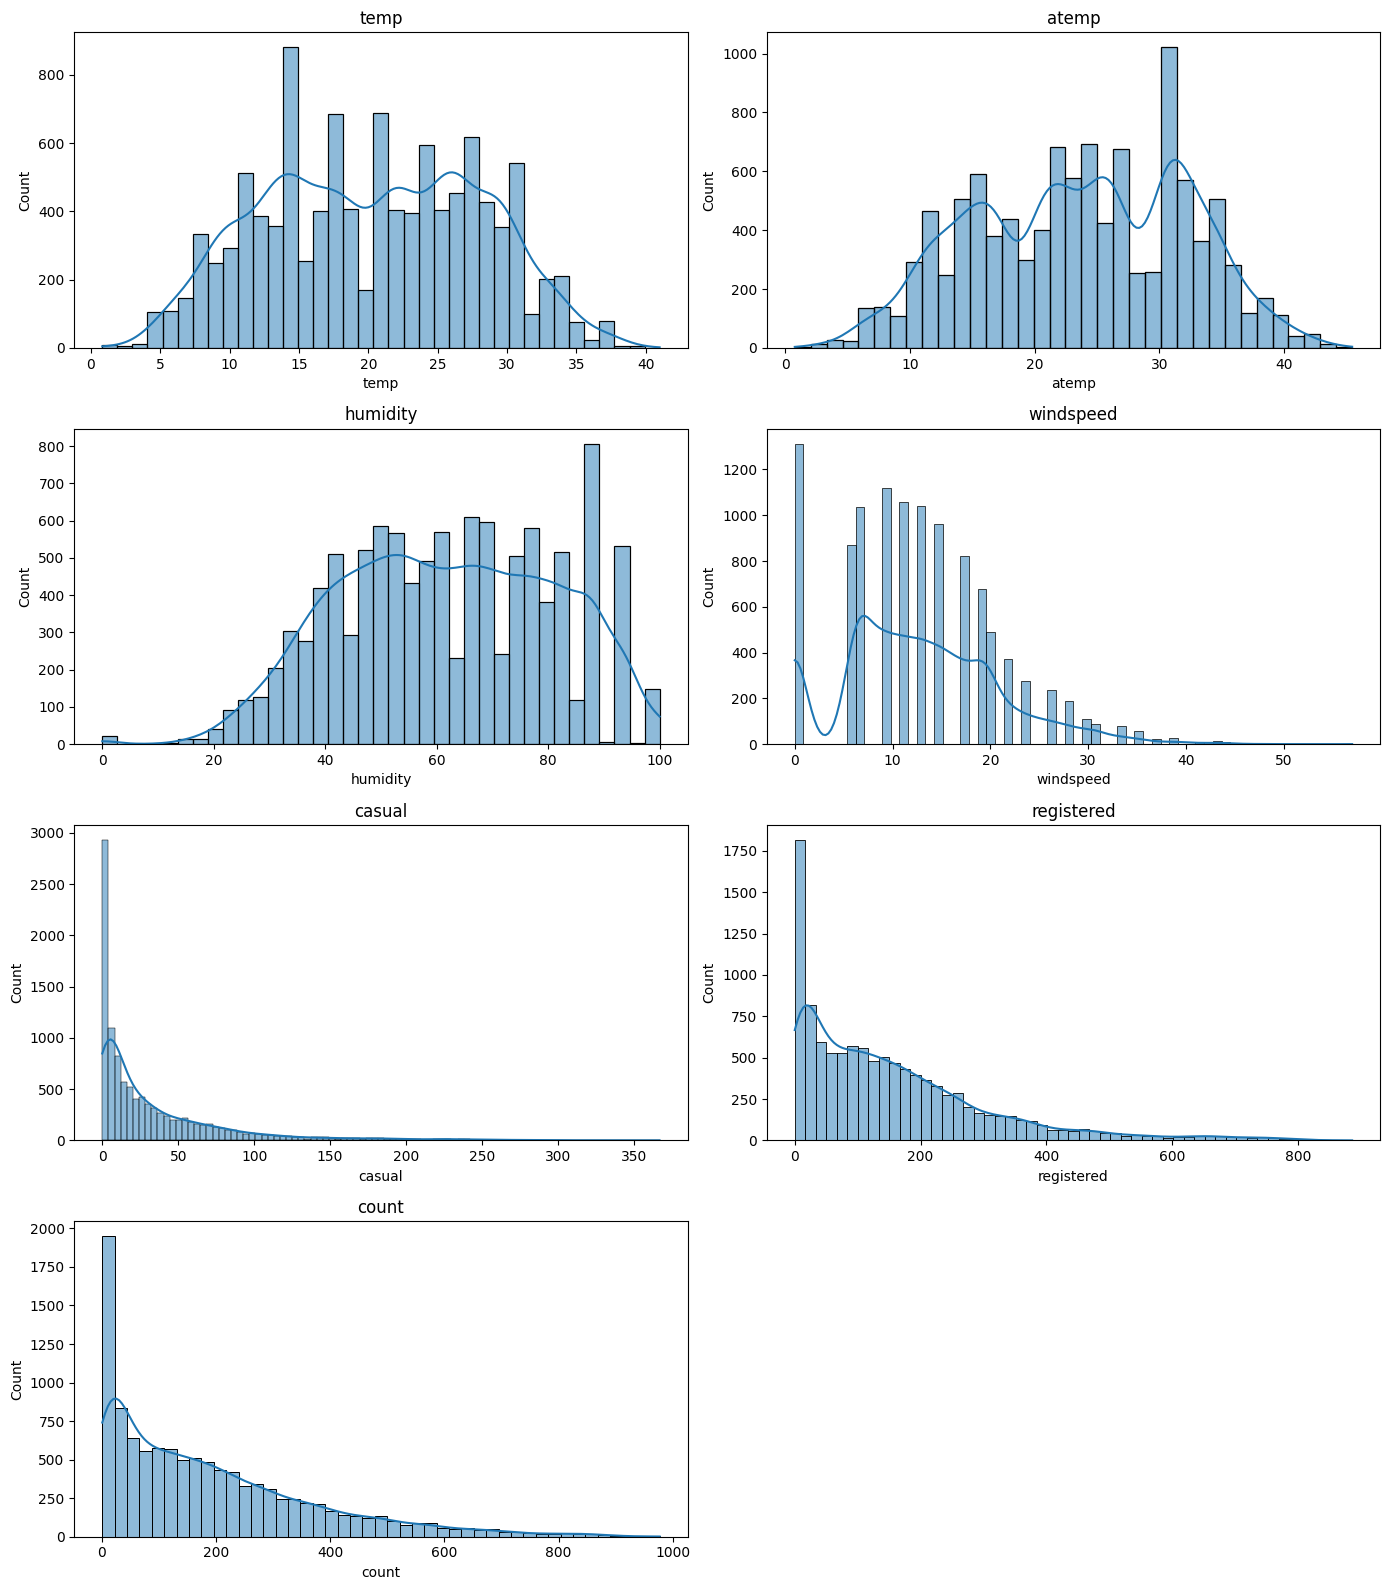

In [304]:
#Univariate analysis
num_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# **Insight**

- `Temperature (temp) and feels-like temperature (atemp)` are approximately `normally distributed`, with most observations concentrated between 10°C and 30°C.

- `Humidity values are mostly between 40% and 90%`, indicating that the majority of observations occurred under moderate to high humidity conditions.

- `Windspeed is right-skewed`, with most observations having low to moderate wind speeds and very few instances of high wind speeds.

- Casual, registered, and total bike rental counts (count) are all highly right-skewed`, where most observations have lower rental counts and only a few have very high counts.

- `The registered user count is generally higher than the casual user count`, suggesting that most bike rentals come from registered users.

- Overall, several variables, especially windspeed, casual, registered, and count, are not normally distributed and contain long right tails.

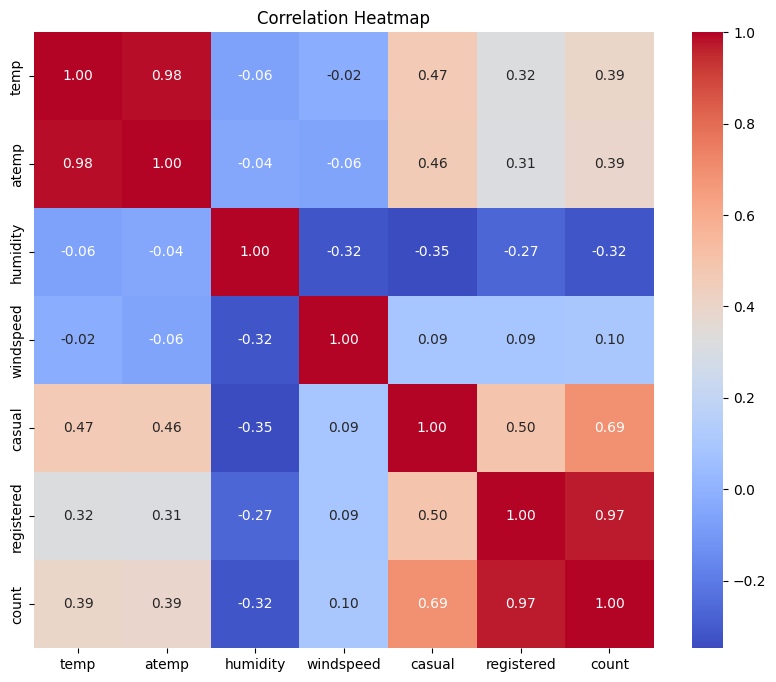

In [119]:
#Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# **Insight**

* **Temperature (`temp`) and feels-like temperature (`atemp`)** have a **very strong positive correlation (0.98)**, indicating they provide almost the same information.
* **Registered users** have the **strongest positive correlation with total bike rentals (`count`) (0.97)**, showing they contribute the most to overall rentals.
* **Casual users** also have a **strong positive correlation with total rentals (0.69)**, but their contribution is lower than registered users.
* **Temperature** has a **moderate positive correlation with bike rentals (0.39)**, suggesting rentals increase as temperature rises.
* **Humidity** has a **moderate negative correlation with bike rentals (-0.32)**, indicating higher humidity is associated with fewer rentals.
* **Windspeed** has **almost no correlation with bike rentals (0.10)**, suggesting it has little impact on rental demand.
* Since **`temp` and `atemp` are highly correlated**, one of them can be removed during model building to reduce multicollinearity.


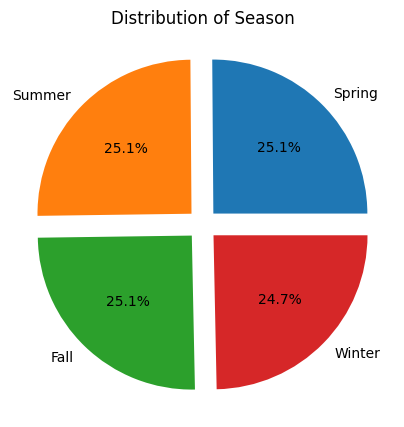

In [216]:
#Distribution of season

plt.figure(figsize=(12, 5))
plt.pie(df['season'].value_counts(), explode = [0.1, 0.1, 0.1, 0.1], labels=['Spring', 'Summer', 'Fall', 'Winter'], autopct='%1.1f%%')
plt.title('Distribution of Season')
plt.show()

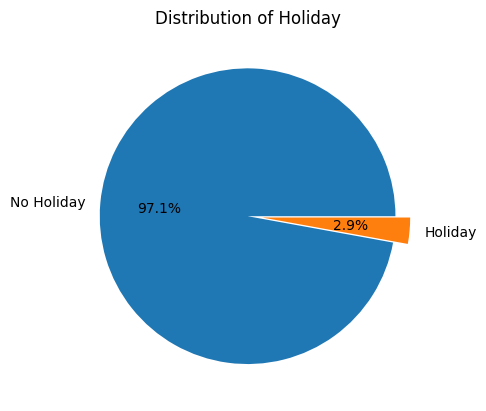

In [217]:
plt.pie(df['holiday'].value_counts(),explode=[0,0.1], labels=['No Holiday', 'Holiday'], autopct='%1.1f%%')
plt.title('Distribution of Holiday')
plt.show()

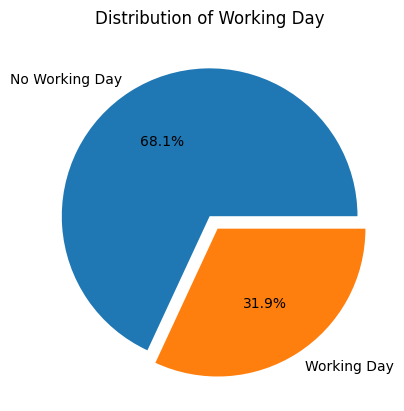

In [218]:
plt.pie(df['workingday'].value_counts(),explode=[0,0.1], labels=['No Working Day', 'Working Day'], autopct='%1.1f%%')
plt.title('Distribution of Working Day')
plt.show()

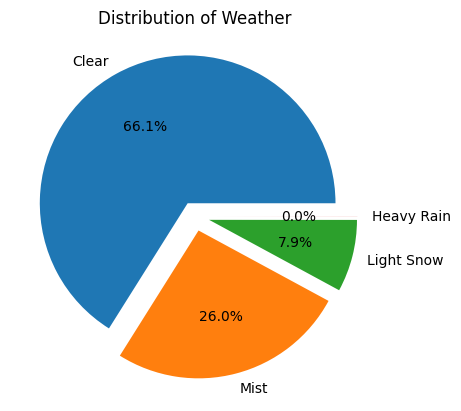

In [219]:
plt.pie(df['weather'].value_counts(),explode=[0.1,0.1,0.1,0.1], labels=['Clear', 'Mist', 'Light Snow', 'Heavy Rain'], autopct='%1.1f%%')
plt.title('Distribution of Weather')
plt.show()

# **Insight**

#### **Season**

* The dataset is **evenly distributed across all four seasons**, with each season contributing about **25%** of the observations.
* **Winter** has a slightly lower share (**24.7%**) compared to the other seasons.
* Overall, there is **no significant class imbalance** in the `season` variable.

#### **Holiday**

* The dataset contains **very few holidays (2.9%)**, while **97.1%** of the observations are on **non-holidays**.
* This indicates that most bike rental records were collected on regular days.

#### **Working Day**

* **68.1%** of the observations are from **non-working days**, while **31.9%** are from **working days**.
* The dataset contains more records for non-working days than working days.

#### **Weather**

* **Clear weather** is the most common condition, accounting for **66.1%** of the observations.
* **Misty weather** represents **26.0%**, while **Light Snow** accounts for **7.9%**.
* **Heavy Rain** is almost absent (**0.0%**), indicating that very few observations were recorded under extreme weather conditions.


# **3. Detecting Outliers**

In [229]:
num_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

outliers = df[outlier_mask]

print("Number of outlier rows:", len(outliers))
print(outliers.head())

Number of outlier rows: 1368
               datetime  season     holiday      workingday weather  temp  \
175 2011-01-08 14:00:00  spring  no_holiday  no_working_day   clear  8.20   
178 2011-01-08 17:00:00  spring  no_holiday  no_working_day   clear  6.56   
194 2011-01-09 09:00:00  spring  no_holiday  no_working_day   clear  4.92   
196 2011-01-09 11:00:00  spring  no_holiday  no_working_day   clear  6.56   
265 2011-01-12 12:00:00  spring  no_holiday     working_day   clear  8.20   

     atemp  humidity  windspeed  casual  registered  count  year  month  \
175  8.335        32    32.9975      12          83     95  2011      1   
178  6.060        37    36.9974       5          64     69  2011      1   
194  3.790        46    35.0008       0          19     19  2011      1   
196  6.060        40    35.0008       2          47     49  2011      1   
265  7.575        47    39.0007       3          52     55  2011      1   

       weekday  day  hour  
175   Saturday    8    14  
1

In [230]:
for col in num_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    print(col, "->", df[(df[col] < lower) | (df[col] > upper)].shape[0], "outliers")

temp -> 0 outliers
atemp -> 0 outliers
humidity -> 22 outliers
windspeed -> 227 outliers
casual -> 749 outliers
registered -> 423 outliers
count -> 300 outliers


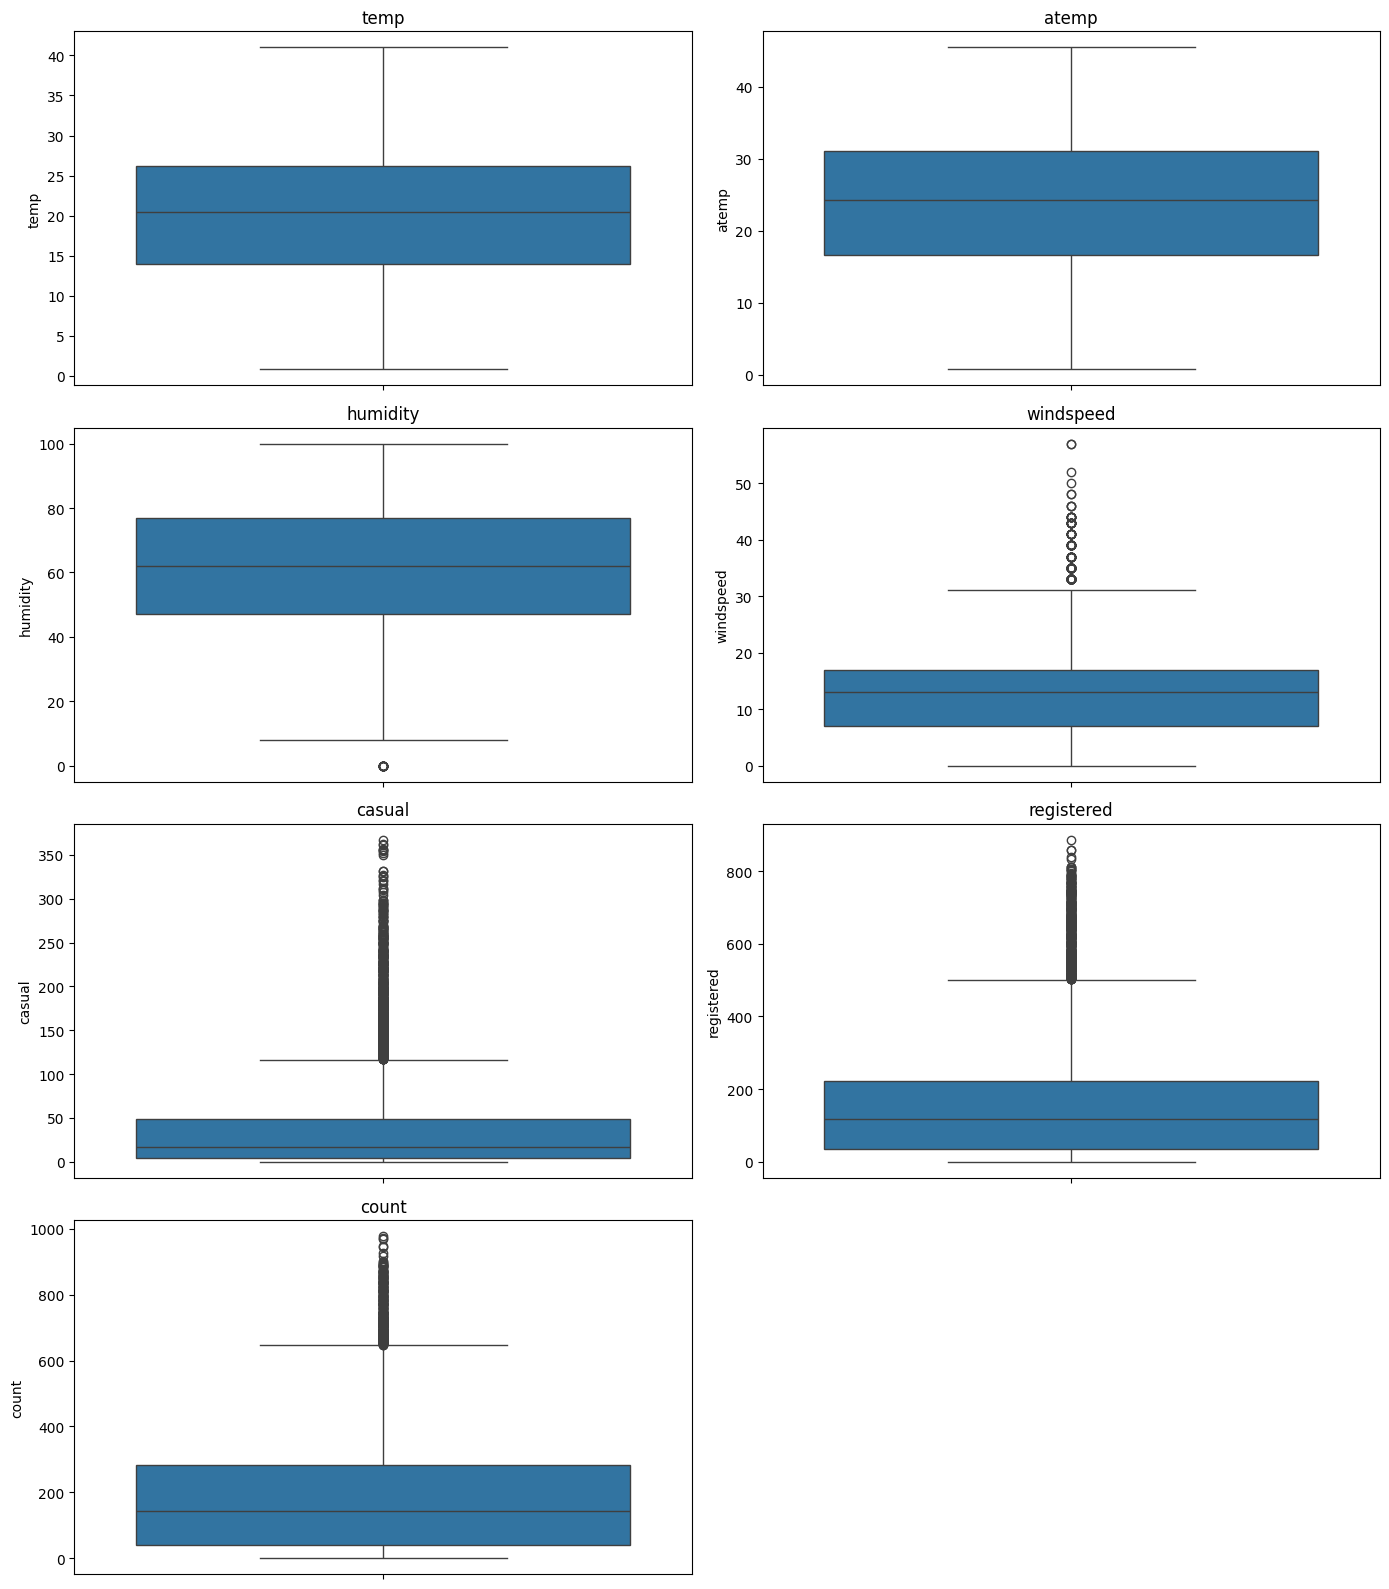

In [231]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### **Insights from Outlier Analysis**

* **Temperature (`temp`)** and **feels-like temperature (`atemp`)** have **no outliers**, indicating these variables are well-distributed without any extreme values.
* **Humidity** contains **22 outliers**, suggesting only a few observations have unusually low or high humidity levels.
* **Windspeed** has **227 outliers**, indicating the presence of several extreme windspeed values, mostly at the higher end.
* **Casual user rentals** have the **highest number of outliers (749)**, showing that on some occasions, casual rentals were significantly higher than usual.
* **Registered user rentals** contain **423 outliers**, reflecting periods of exceptionally high demand from registered users.
* The **total rental count (`count`)** has **300 outliers**, indicating a number of days with unusually high bike rental activity.
* Overall, **outliers are mainly present in rental-related variables (`casual`, `registered`, and `count`)**, while the weather-related variables show relatively few or no outliers. These extreme values are likely due to genuine peak demand periods rather than data errors and should be handled carefully during model building.


# **4. Statistical Testing**

# **4.1 Does Working Day affect bike rentals? (Working Day has effect on number of electric cycles rented)**


H0: Average rentals are same on working and non-working days.

H1: Average rentals are different.

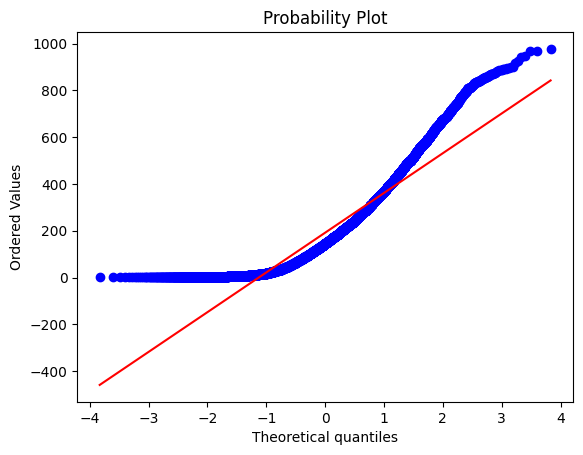

In [232]:
stats.probplot(df["count"],dist="norm",plot=plt)
plt.show()

In [233]:
sample=df["count"].sample(5000,random_state=42)

shapiro(sample)

ShapiroResult(statistic=np.float64(0.874423998787609), pvalue=np.float64(4.045612969035238e-53))

In [235]:
working = df[df["workingday"] == 'working_day']["count"]
nonworking = df[df["workingday"] == 'no_working_day']["count"]

# The rest of your code remains the same
stat, p = levene(working, nonworking)

print("Levene Statistic:", stat)
print("P-value:", p)

alpha = 0.05

if p > alpha:
    print("Equal variance assumption is satisfied.")
else:
    print("Equal variance assumption is violated.")

Levene Statistic: 0.004972848886504472
P-value: 0.9437823280916695
Equal variance assumption is satisfied.


In [236]:
alpha=0.05

t_stat,p_value=ttest_ind(working, nonworking, equal_var=True)

print("t-statistic:",t_stat)
print("p-value:",p_value)

if p_value<alpha:
    print("Reject Null Hypothesis, Average rentals are different.")
else:
    print("Fail to Reject Null Hypothesis, Average rentals are same on working and non-working days.")

t-statistic: 1.2096277376026694
p-value: 0.22644804226361348
Fail to Reject Null Hypothesis, Average rentals are same on working and non-working days.


### **Insights: Effect of Working Day on Bike Rentals (2-Sample t-test)**

#### **Assumption Checks**

* The **Q-Q plot** shows that the data points deviate considerably from the reference line, indicating that the **`count` variable is not normally distributed**.
* The **Shapiro-Wilk test** also confirms this with a **p-value = 4.05 × 10⁻⁵³ (< 0.05)**. Therefore, the null hypothesis of normality is rejected.
* Despite the violation of normality, the dataset contains **10,886 observations**, making the **t-test robust** due to the **Central Limit Theorem (CLT)**.
* The **Levene's test** produced a **p-value = 0.944 (> 0.05)**, indicating that the variances of the two groups (working day and non-working day) are **equal**. Hence, the equal variance assumption is satisfied.

#### **Hypothesis Test Results**

* **t-statistic:** 1.209
* **p-value:** 0.2264
* **Significance level (α):** 0.05

Since the **p-value (0.2264) is greater than 0.05**, we **fail to reject the null hypothesis**.

#### **Inference**

* There is **no statistically significant difference** in the average number of bike rentals between **working days** and **non-working days**.
* This suggests that the **working day variable alone does not have a significant impact on overall bike rental demand** in the dataset.
* Other factors such as **season, weather, temperature, humidity, and time of day** are likely to have a greater influence on bike rental demand.


# **4.2 Are rentals different across Seasons?**

(No. of cycles rented similar or different in different seasons)

H0: Average rentals are same across all seasons.

H1: At least one season has different average rentals.

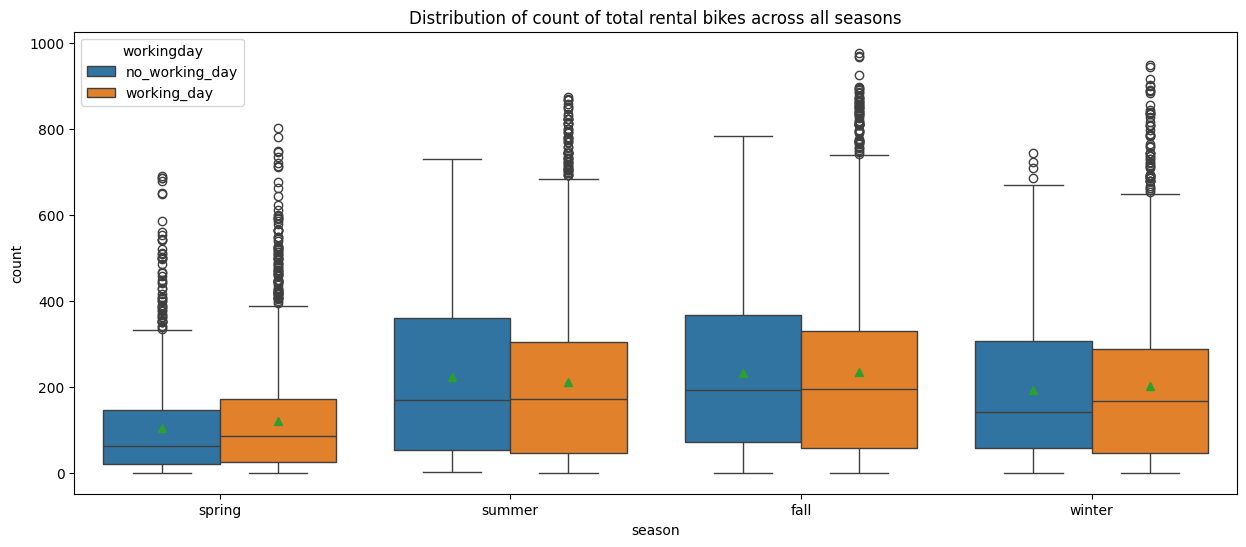

In [223]:
plt.figure(figsize = (15,6))

plt.title("Distribution of count of total rental bikes across all seasons")
sns.boxplot(data = df, x = "season", y = "count", hue = 'workingday', showmeans = True)
plt.show()

In [239]:
from scipy.stats import levene

spring = df[df["season"] == 'spring']["count"]
summer = df[df["season"] == 'summer']["count"]
fall = df[df["season"] == 'fall']["count"]
winter = df[df["season"] == 'winter']["count"]

stat, p = levene(spring, summer, fall, winter)

print("Levene Statistic:", stat)
print("P-value:", p)

alpha = 0.05

if p > alpha:
    print("Equal variance assumption is satisfied.")
else:
    print("Equal variance assumption is violated.")

Levene Statistic: 187.7706624026276
P-value: 1.0147116860043298e-118
Equal variance assumption is violated.


In [249]:
from scipy.stats import f_oneway

F, p = f_oneway(spring, summer, fall, winter)

print("F-statistic:", F)
print("p-value:", p)

alpha = 0.05

if p<alpha:
    print("Reject Null Hypothesis, At least one season has different average rentals.")
else:
    print("Fail to Reject Null Hypothesis, Average rentals are same across all seasons.")

F-statistic: 236.94671081032098
p-value: 6.164843386499654e-149
Reject Null Hypothesis, At least one season has different average rentals.


### **Insights: Effect of Season on Bike Rentals (One-Way ANOVA)**

#### **Assumption Check**

* The boxplot shows that the distribution of bike rentals varies across seasons and contains several outliers.
* **Levene's test** returned a **p-value = 1.01 × 10⁻¹¹⁸ (< 0.05)**, indicating that the **equal variance assumption is violated**.
* Although this assumption is violated, the dataset contains **10,886 observations**, and ANOVA is generally robust for large sample sizes. Therefore, the analysis is continued.

#### **ANOVA Results**

* **F-statistic:** 236.95
* **p-value:** 6.16 × 10⁻¹⁴⁹
* **Significance level (α):** 0.05

Since the **p-value is much smaller than 0.05**, we **reject the null hypothesis**.

#### **Inference**

* There is a **statistically significant difference** in the average number of bike rentals across the four seasons.
* This indicates that **season has a significant impact on bike rental demand**.
* From the boxplot, **Fall (Season 3)** has the highest median bike rentals, while **Spring (Season 1)** has the lowest, suggesting that demand varies noticeably with seasonal changes.


# **4.3 Are rentals different across Weather?**

(No. of cycles rented similar or different in different weather)



H0: Average rentals are same across all weather conditions.

H1: At least one weather category has different rentals.

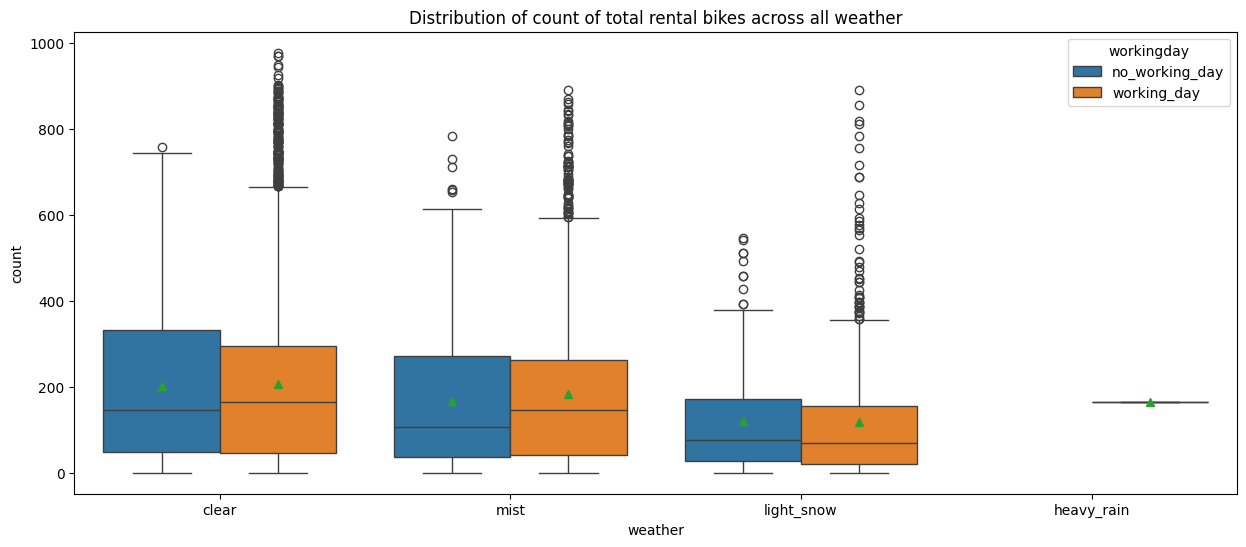

In [242]:
plt.figure(figsize = (15,6))

plt.title("Distribution of count of total rental bikes across all weather")
sns.boxplot(data = df, x = "weather", y = "count", hue = 'workingday',  showmeans = True)
plt.show()

In [245]:
from scipy.stats import levene

clear = df[df["weather"] == 'clear']["count"]
mist = df[df["weather"] == 'mist']["count"]
light_snow = df[df["weather"] == 'light_snow']["count"]
heavy_rain = df[df["weather"] == 'heavy_rain']["count"]

stat, p = levene(clear, mist, light_snow, heavy_rain)

print("Levene Statistic:", stat)
print("P-value:", p)

alpha = 0.05

if p > alpha:
    print("Equal variance assumption is satisfied.")
else:
    print("Equal variance assumption is violated.")

Levene Statistic: 54.85106195954556
P-value: 3.504937946833238e-35
Equal variance assumption is violated.


In [246]:
from scipy.stats import f_oneway

F, p = f_oneway(clear, mist, light_snow, heavy_rain)

print("F-statistic:", F)
print("p-value:", p)

alpha = 0.05

if p<alpha:
    print("Reject Null Hypothesis, At least one weather category has different rentals.")
else:
    print("Fail to Reject Null Hypothesis, Average rentals are same across all weather conditions. ")

F-statistic: 65.53024112793265
p-value: 5.482069475935669e-42
Reject Null Hypothesis, At least one weather category has different rentals.


### **Insights: Effect of Weather on Bike Rental Demand (One-Way ANOVA)**

#### **Assumption Check**

* The boxplot shows that the distribution of bike rentals varies across different weather conditions and contains several outliers.
* **Levene's test** returned a **p-value = 3.50 × 10⁻³⁵ (< 0.05)**, indicating that the **equal variance assumption is violated**.
* Despite this violation, the dataset has **10,886 observations**, and ANOVA is generally robust for large sample sizes. Therefore, the analysis is continued.

#### **ANOVA Results**

* **F-statistic:** 65.53
* **p-value:** 5.48 × 10⁻⁴²
* **Significance level (α):** 0.05

Since the **p-value is much smaller than 0.05**, we **reject the null hypothesis**.

#### **Inference**

* There is a **statistically significant difference** in the average number of bike rentals across different weather conditions.
* This indicates that **weather is a significant factor influencing bike rental demand**.
* From the boxplot, **clear weather** has the highest median bike rentals, while **light snow** has the lowest median rentals. This suggests that bike rental demand decreases as weather conditions become less favorable.
* The **heavy rain** category contains very few observations, so conclusions for this weather condition should be interpreted with caution.


# **4.4 Is Weather dependent on Season?**

(Weather is dependent on season (check between 2 predictor variable))

H0: Season and Weather are independent.

H1: Season and Weather are associated.

In [305]:
table=pd.crosstab(
    df["season"],
    df["weather"]
)

table

weather,clear,mist,light_snow,heavy_rain
season,,,,
spring,1759,715,211,1
summer,1801,708,224,0
fall,1930,604,199,0
winter,1702,807,225,0


In [306]:
chi2,p,dof,expected=chi2_contingency(table)

print("Chi-square:",chi2)
print("p-value:",p)
print("Degrees of Freedom:",dof)

expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print(expected_df.round(2))

Chi-square: 49.158655596893624
p-value: 1.549925073686492e-07
Degrees of Freedom: 9
weather    clear    mist  light_snow  heavy_rain
season                                          
spring   1774.55  699.26      211.95        0.25
summer   1805.60  711.49      215.66        0.25
fall     1805.60  711.49      215.66        0.25
winter   1806.26  711.75      215.74        0.25


In [307]:
(expected>=5).all()

np.False_

# **Insight**

One of the assumptions of the Chi-square Test of Independence is:

* Every expected frequency should be at **least 5** (or at least 80% of cells ≥ 5 and no expected count < 1).

* **The Heavy Rain** category has an expected frequency of only **0.25**, which is much less than 5. Therefore, the **Chi-square assumption is violated.**

In [308]:
#Remove Heavy Rain Category

df_chi = df[df["weather"] != "heavy_rain"]

table = pd.crosstab(df_chi["season"], df_chi["weather"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:",chi2)
print("p-value:",p)
print("Degrees of Freedom:",dof)

expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns)

print(expected_df.round(2))

print((expected >= 5).all())

Chi-square: 46.10145731073249
p-value: 2.8260014509929343e-08
Degrees of Freedom: 6
weather    clear    mist  light_snow
season                              
spring   1774.05  699.06      211.89
summer   1805.76  711.56      215.68
fall     1805.76  711.56      215.68
winter   1806.42  711.82      215.76
True


### **Insights: Relationship Between Season and Weather (Chi-Square Test of Independence)**

#### **Assumption Check**

* The **Heavy Rain** category was removed because it contained only one observation, resulting in expected frequencies below 5.
* After removing this category, **all expected frequencies are greater than 5**, so the **Chi-square test assumption is satisfied**.

#### **Hypothesis Test Results**

* **Chi-square statistic:** 46.10
* **Degrees of Freedom:** 6
* **p-value:** 2.83 × 10⁻⁸
* **Significance level (α):** 0.05

Since the **p-value is less than 0.05**, we **reject the null hypothesis**.

#### **Inference**

* There is a **statistically significant association** between **season** and **weather**.
* This indicates that the distribution of weather conditions varies across different seasons, meaning **weather is dependent on season**.
* Therefore, **season and weather are not independent variables**, and seasonal changes influence the type of weather experienced.

**Business Insight:** Since both **season** and **weather** significantly influence bike rental demand and are also associated with each other.
